In [42]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd

In [43]:
df = pd.read_csv('/Users/shivendragupta/Desktop/Machine Learning/iris.csv')

In [45]:
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [37]:
import seaborn as sns

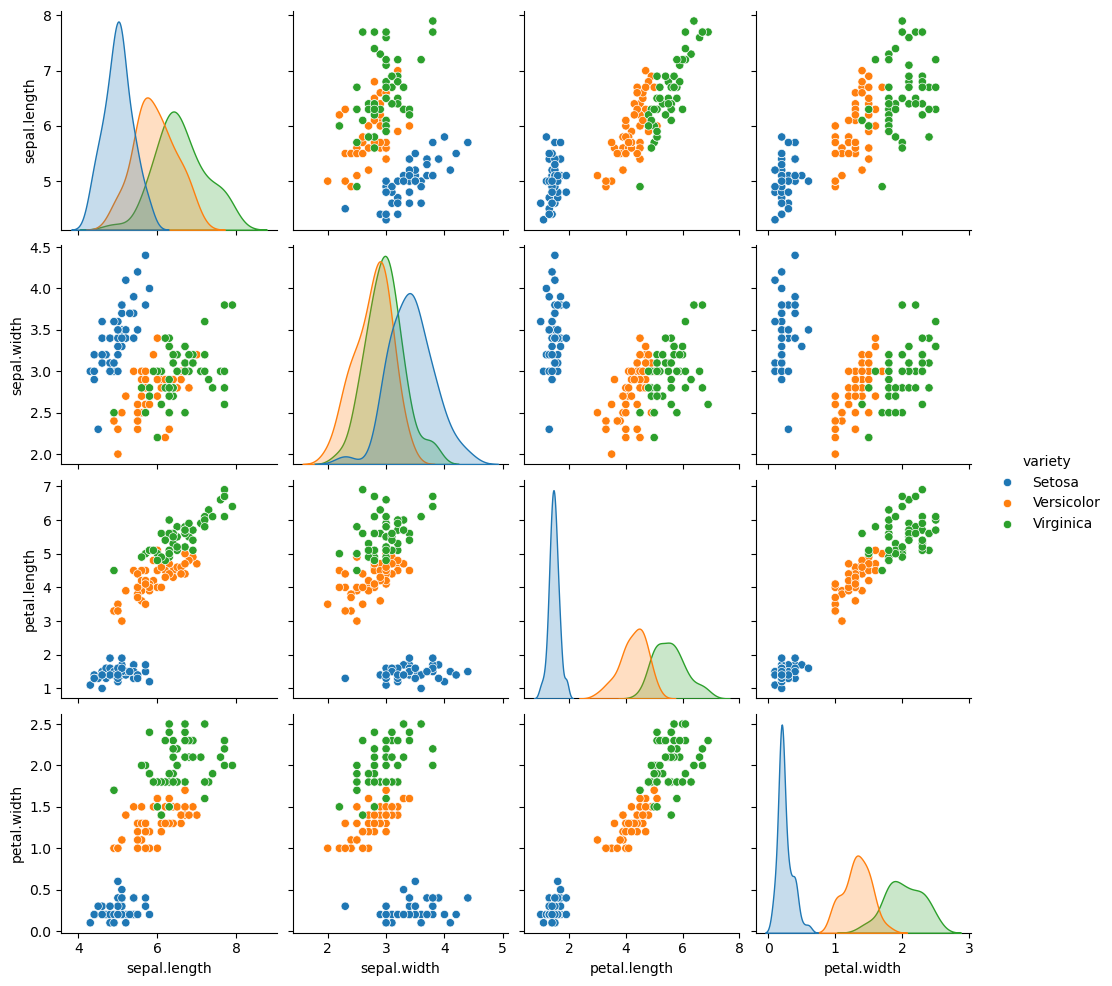

In [49]:
sns.pairplot(df,hue='variety')

In [50]:
from sklearn.preprocessing import LabelEncoder

In [53]:
le = LabelEncoder()
y_trs = le.fit_transform(df.iloc[:,-1])

In [56]:
X = df.iloc[:,0:2]
X

,sepal.length,sepal.width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [58]:
clr1 = LogisticRegression()
clr2 = KNeighborsClassifier()
clr3 = RandomForestClassifier()

In [59]:
estimators = [('lr',clr1),('knn',clr2),('rf',clr3)]

In [61]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.81
knn 0.76
rf 0.73


### Hard Voting (Default)

In [62]:
from sklearn.ensemble import VotingClassifier

In [67]:
vc = VotingClassifier(estimators=estimators)
x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


In [68]:
vc_soft = VotingClassifier(estimators=estimators,voting='soft')
x = cross_val_score(vc_soft,X,y,cv=10,scoring='accuracy')
print(np.round(np.mean(x),2))

0.77


In [69]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc = VotingClassifier(estimators=estimators,voting='soft',weights=[i,j,k])
            x = cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print("for i={},j={},k={}".format(i,j,k),np.round(np.mean(x),2))
            

for i=1,j=1,k=1 0.76
for i=1,j=1,k=2 0.74
for i=1,j=1,k=3 0.73
for i=1,j=2,k=1 0.76
for i=1,j=2,k=2 0.75
for i=1,j=2,k=3 0.75
for i=1,j=3,k=1 0.76
for i=1,j=3,k=2 0.75
for i=1,j=3,k=3 0.75
for i=2,j=1,k=1 0.77
for i=2,j=1,k=2 0.76
for i=2,j=1,k=3 0.75
for i=2,j=2,k=1 0.77
for i=2,j=2,k=2 0.76
for i=2,j=2,k=3 0.76
for i=2,j=3,k=1 0.75
for i=2,j=3,k=2 0.76
for i=2,j=3,k=3 0.76
for i=3,j=1,k=1 0.79
for i=3,j=1,k=2 0.77
for i=3,j=1,k=3 0.75
for i=3,j=2,k=1 0.77
for i=3,j=2,k=2 0.76
for i=3,j=2,k=3 0.77
for i=3,j=3,k=1 0.78
for i=3,j=3,k=2 0.76
for i=3,j=3,k=3 0.77
